# Hyperparameter Tuning

## Objective

The objective of this notebook is to optimize the Logistic Regression classifier by tuning its hyperparameters. The optimized model will be evaluated and compared with the baseline model to improve customer churn prediction performance.

# Import Libraries

In [8]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt

# Load Processed Data

In [2]:
X_train = joblib.load("../data/X_train.pkl")
X_test = joblib.load("../data/X_test.pkl")

y_train = joblib.load("../data/y_train.pkl")
y_test = joblib.load("../data/y_test.pkl")

# Baseline CatBoost Model

In [9]:
baseline_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

baseline_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

# Define Hyperparameter Search Space

In [11]:
param_grid = {

    "C": [
        0.01,
        0.1,
        1,
        10,
        100
    ],

    "penalty": [
        "l2"
    ],

    "solver": [
        "lbfgs"
    ]

}

# Hyperparameter Optimization

In [12]:
grid_search = GridSearchCV(

    estimator=LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    param_grid=param_grid,

    scoring="roc_auc",

    cv=5,

    n_jobs=-1,

    verbose=2

)

# Train the Optimizer

In [13]:
grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see ho

# Best Hyperparameters

In [14]:
grid_search.best_params_

{'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}

# Best Cross Validation Score

In [15]:
grid_search.best_score_

np.float64(0.8591515706106716)

# Best Tuned Model

In [16]:
best_model = grid_search.best_estimator_

# Make Predictions

In [17]:
predictions = best_model.predict(X_test)

probabilities = best_model.predict_proba(X_test)[:,1]

# Model Evaluation

In [18]:
results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Value":[

        accuracy_score(y_test,predictions),

        precision_score(y_test,predictions),

        recall_score(y_test,predictions),

        f1_score(y_test,predictions),

        roc_auc_score(y_test,probabilities)

    ]

})

results

,Metric,Value
0,Accuracy,0.804549
1,Precision,0.642651
2,Recall,0.596257
3,F1 Score,0.618585
4,ROC AUC,0.842553


# Classification Report

In [19]:
print(classification_report(
    y_test,
    predictions
))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1033
           1       0.64      0.60      0.62       374

    accuracy                           0.80      1407
   macro avg       0.75      0.74      0.74      1407
weighted avg       0.80      0.80      0.80      1407



# Save the Final Model

In [20]:
joblib.dump(
    best_model,
    "../models/final_model.pkl"
)

['../models/final_model.pkl']

# Threshold Optimization
## Objective
Instead of using the default classification threshold (0.5), this section evaluates multiple probability thresholds to identify the value that provides the best balance between precision and recall for customer churn prediction.

In [21]:
thresholds = np.arange(0.1, 1.0, 0.05)

results = []

for threshold in thresholds:

    predictions = (probabilities >= threshold).astype(int)

    results.append({

        "Threshold": threshold,

        "Accuracy": accuracy_score(y_test, predictions),

        "Precision": precision_score(y_test, predictions),

        "Recall": recall_score(y_test, predictions),

        "F1 Score": f1_score(y_test, predictions)

    })

threshold_df = pd.DataFrame(results)

threshold_df

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.10,0.627576,0.411972,0.938503,0.572594
1,0.15,0.667377,0.437831,0.885027,0.585841
2,0.20,0.698650,0.464080,0.863636,0.603738
3,0.25,0.723525,0.487725,0.796791,0.605076
4,0.30,0.751955,0.523020,0.759358,0.619411
5,0.35,0.768301,0.548387,0.727273,0.625287
6,0.40,0.783227,0.576497,0.695187,0.630303
7,0.45,0.798863,0.614610,0.652406,0.632944
8,0.50,0.804549,0.642651,0.596257,0.618585
9,0.55,0.803838,0.662252,0.534759,0.591716


## Threshold Performance

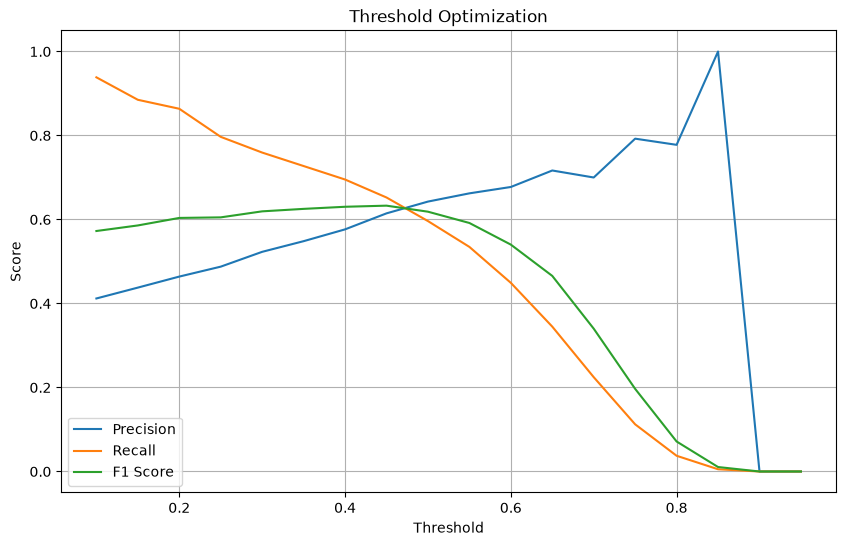

In [22]:
plt.figure(figsize=(10,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    label="F1 Score"
)

plt.xlabel("Threshold")

plt.ylabel("Score")

plt.title("Threshold Optimization")

plt.legend()

plt.grid(True)

plt.show()

## Select the Best Threshold

In [23]:
best_threshold = threshold_df.loc[
    threshold_df["F1 Score"].idxmax(),
    "Threshold"
]

print(f"Best Threshold: {best_threshold:.2f}")

Best Threshold: 0.45


## Predictions with Optimized Threshold

In [24]:
optimized_predictions = (
    probabilities >= best_threshold
).astype(int)

In [25]:
print(classification_report(
    y_test,
    optimized_predictions
))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1033
           1       0.61      0.65      0.63       374

    accuracy                           0.80      1407
   macro avg       0.74      0.75      0.75      1407
weighted avg       0.80      0.80      0.80      1407



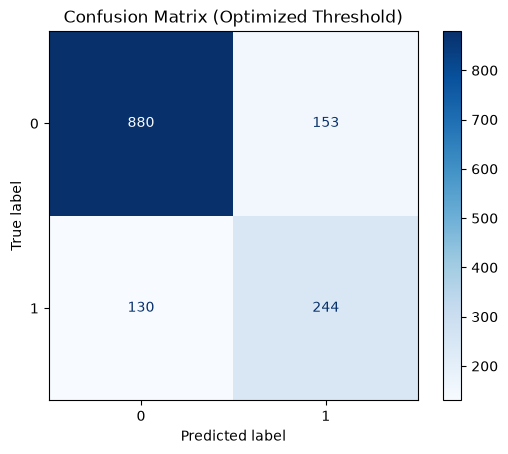

In [26]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    optimized_predictions,
    cmap="Blues"
)

plt.title("Confusion Matrix (Optimized Threshold)")

plt.show()

### Business Insight

The optimized model correctly identifies **65%** of customers who actually churn (Recall), while **62%** of customers flagged as at-risk truly churn (Precision).

The 130 missed churners (False Negatives) represent the biggest business risk, as these customers leave without triggering any retention action. Given the cost of losing a customer typically outweighs the cost of a retention offer, further threshold tuning could push Recall higher to catch more at-risk customers, even at the expense of some Precision.